In [1]:
# Required libreries

import numpy as np
import matplotlib.pyplot as plt
import neuron
from neuron import h


In [2]:
# Model morphology

As = 0.015 # As: soma area in mm2
Ad = 0.035 # Ad: dendrite area in mm2

soma = h.Section(name='soma')
soma.L    = 70  # Soma length in μm
soma.diam = 68  # Soma diameter in μm
soma.nseg = 1   # Number of segments of the soma
soma.cm   = 1   # Membrane capacitance in μF/cm2     

dend = h.Section(name='dend')
dend.L     = 680  # Dendrite length in μm
dend.diam  = 17   # Dendrite diameter in μm
dend.nseg  = 1    # Number of segments of the dendrite
dend.cm    = 1    # Membrane capacitance in μF/cm2   

# Dendrite sizes chosen to have coupling between soma and dendrite with a conductance of 1.75 μS,
# corrisponding to an axial resistance (dend.ri) of 0.57 MΩ.

h.celsius  = 30   # Temperature in Celsius degrees
dend.connect(soma(1),0);  # To connect the top of the dendrite to the bottom of the soma


In [3]:
# -------------------------------------------------------------------------------------------------------------------------------
# Model mechanisms
# -------------------------------------------------------------------------------------------------------------------------------

# In the soma
soma.insert('KNa') 
soma.insert('KDR') 
soma.insert('Na') 
soma.insert('KS')
soma.insert('KA')
soma.insert('leak')

# In the dendrite
dend.insert('NaP') 
dend.insert('KAR')
dend.insert('KCa')
dend.insert('Ca')
dend.insert('leak') 

# Mechanisms added by Dalla Porta
dend.insert('Ih') 
soma.insert('IM'); 

# Modifing mechanisms parameters
soma.gL_leak = 0.0667e-3*0.3 
dend.gL_leak = 0.0667e-3*0.3 


In [4]:
# ------------------------------------------------------------------------------------------------------------------------------
# Binary search for the holding current
# ------------------------------------------------------------------------------------------------------------------------------


# Normalization current clamp to reach the holding potential
iclampN = h.IClamp(soma(0.5)) # Clamp performed on the soma at coordinate 0.5: exactly at its center 
iclampN.delay = 0 # Clamp start delay in ms
iclampN.dur = 8e3 # Clamp duration in ms 
iclampN.amp = 0 # Clamp current amplitude in nA

# Binary search parameters
THP = -70  # Target Holding Potential
IminN, ImaxN = -0.5, 0.5  # Starting values for the binary search
tol = 0.3  # Tolerance on the THP
max_iter = 50  # Maximal number of iterations
target = THP

h.load_file('stdrun.hoc')
# The following 3 lines are required for adaptive integration (to make the code faster)
Hines = h.CVode() 
Hines.active(1) 
Hines.use_local_dt(1) 


# Function to get the holding potential given a holding current amplitude
def get_Vhold(amp):
    
    iclampN.amp = amp 

    v = h.Vector().record(soma(0.5)._ref_v)
    t = h.Vector().record(h._ref_t)

    spike_times = h.Vector()
    nc = h.NetCon(soma(0.5)._ref_v, None, sec=soma)
    nc.threshold = -20
    nc.record(spike_times)

    h.finitialize(-65)
    h.tstop = 2000
    h.run()

    Vhold = float(v[-1])
    n_spikes = int(len(spike_times))

    return Vhold, n_spikes


# Loop to find the right holding current
for _ in range(max_iter):
    ImidN = 0.5 * (IminN + ImaxN)
    Vhold, NS = get_Vhold(ImidN)
    
    if NS != 0:  # There must be no spike when the membrane is at the THP
        ImaxN = ImidN

    if abs(Vhold - target) < tol:
        break

    if Vhold > target:
        ImaxN = ImidN
    else:
        IminN = ImidN

ampN_final = ImidN

iclampN.amp = ampN_final  
#iclampN.amp = 0  # Uncomment the line to delete the holding current


Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt


Changed dt


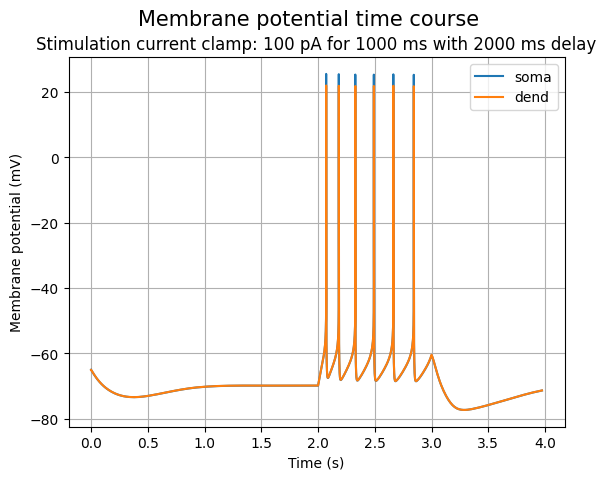

In [5]:
# ------------------------------------------------------------------------------------------------------------------------------
# Membrane potential time course
# ------------------------------------------------------------------------------------------------------------------------------


# Stimulation current clamp. 
iclampS = h.IClamp(dend(0.5))
iclampS.delay = 2000 # ms
iclampS.dur = 1000 # ms 
iclampS.amp = 0.1 # nA

# Vectors to record Na+ channel behaviour (in the soma) over time.
m_inf_Na = h.Vector().record(soma(0.5)._ref_m_inf_Na) # Activation variable at t=inf
h_inf_Na = h.Vector().record(soma(0.5)._ref_h_inf_Na) # Inactivation variable at t=inf  
OP_Na = h.Vector().record(soma(0.5)._ref_OP_Na) # Time dependend opening probability

# Vectors to record Na+ and Ca++ internal concentrations over time.
nai = h.Vector().record(soma(0.5)._ref_nai_KNa)  # [Na+] in the soma
cai = h.Vector().record(dend(0.5)._ref_cai_KCa)  # [Ca++] in the dendrite

vs = h.Vector().record(soma(0.5)._ref_v) # MP in the soma
vd = h.Vector().record(dend(0.5)._ref_v) # MP in the dendrite
t = h.Vector().record(h._ref_t) 

h.load_file('stdrun.hoc')
h.finitialize(-65)
h.tstop = 4000 # ms
h.run()                  

plt.plot(t*1e-3, vs, label='soma')
plt.plot(t*1e-3, vd, label='dend')
plt.xlabel('Time (s)')
plt.ylabel('Membrane potential (mV)')
plt.legend()
plt.title(f'Stimulation current clamp: {int(iclampS.amp*1e3)} pA for {int(iclampS.dur)} ms with {int(iclampS.delay)} ms delay') 
#plt.title(f'Normalization current clamp: {int(iclampN.amp*1e3)} pA') 
plt.suptitle('Membrane potential time course', fontsize=15)
plt.grid();

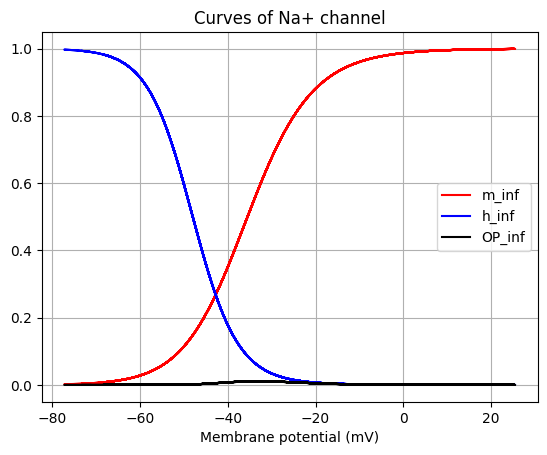

In [6]:
# Activation and inhactivations curves of Na+ channel

m_inf = m_inf_Na
h_inf = h_inf_Na
OP_inf = np.zeros(len(m_inf))
for i in range(len(m_inf)):
    OP_inf[i]=(m_inf[i]**3)*h_inf[i]
plt.plot(vs, m_inf, 'r', label='m_inf')  # Activation variable at t=inf
plt.plot(vs, h_inf, 'b', label='h_inf')  # Inhactivation variable at t=inf
plt.plot(vs, OP_inf, 'k', label='OP_inf') # Opening probability at t=inf
plt.xlabel('Membrane potential (mV)')
plt.legend()
plt.title('Curves of Na+ channel')
plt.grid();

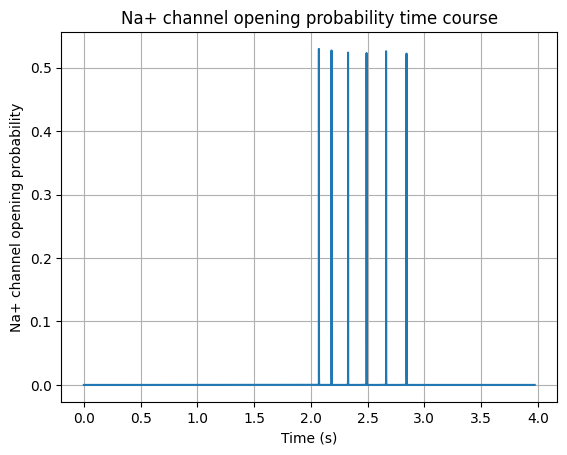

In [7]:
# Na+ channel opening probability time course

plt.plot(t*1e-3, OP_Na)
plt.xlabel('Time (s)')
plt.ylabel('Na+ channel opening probability')
plt.title('Na+ channel opening probability time course')
plt.grid();

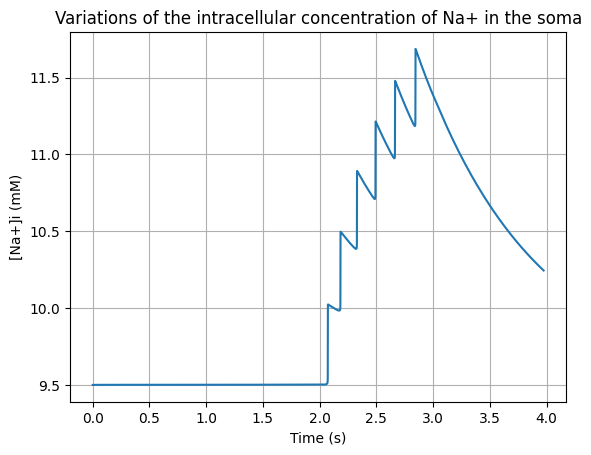

In [8]:
# [Na+]i time course in the soma

plt.plot(t*1e-3, nai)
plt.xlabel('Time (s)')
plt.ylabel('[Na+]i (mM)')
plt.title('Variations of the intracellular concentration of Na+ in the soma')
plt.grid();

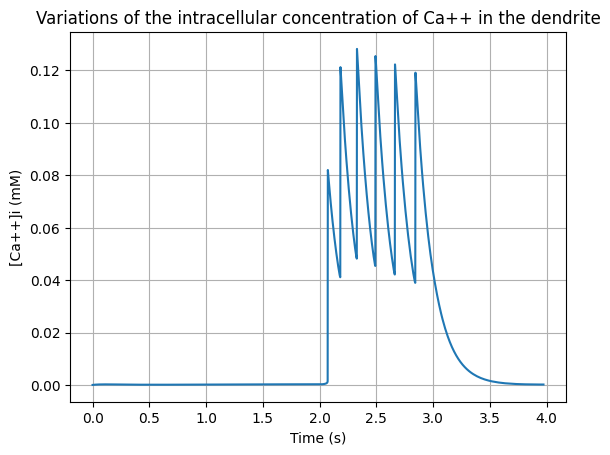

In [9]:
# [Ca++]i time course in the dendrite

plt.plot(t*1e-3, cai)
plt.xlabel('Time (s)')
plt.ylabel('[Ca++]i (mM)')
plt.title('Variations of the intracellular concentration of Ca++ in the dendrite')
plt.grid();

Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt


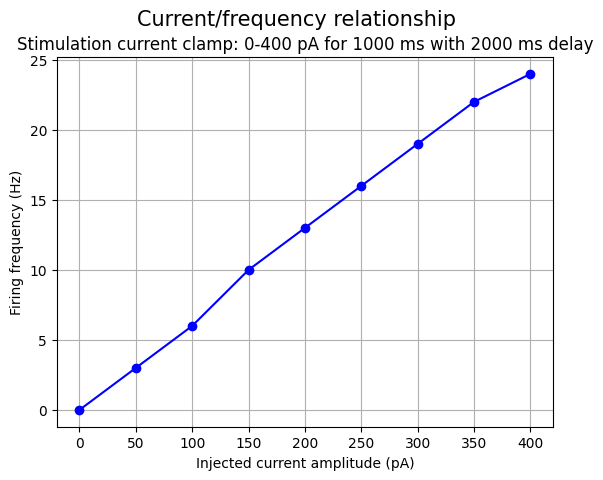

In [10]:
# ------------------------------------------------------------------------------------------------------------------------------
# Current/frequency relationship
# ------------------------------------------------------------------------------------------------------------------------------

I = np.arange(0,0.41,0.05)
freq = np.zeros(len(I))

for i in range (len(I)):
    iclampS = h.IClamp(soma(0.5))
    iclampS.delay = 2000 
    iclampS.dur = 1000
    iclampS.amp = I[i] 

    apc = h.APCount(0.5)
    apc.thresh = -20  

    v = h.Vector().record(soma(0.5)._ref_v)             
    t = h.Vector().record(h._ref_t) 

    h.finitialize(-65)
    h.tstop = 4000
    h.run()                         
    freq[i] = 1000*apc.n/(iclampS.dur)  
    
plt.plot(I*1000, freq, 'bo-')
plt.xlabel('Injected current amplitude (pA)')
plt.ylabel('Firing frequency (Hz)')
plt.suptitle(f'Current/frequency relationship', fontsize=15) 
plt.title(f'Stimulation current clamp: {int(I[0])}-{int(I[-1]*1e3)} pA for {int(iclampS.dur)} ms with {int(iclampS.delay)} ms delay')
plt.grid();